# 1. Pneumonia Detection from Chest X-ray Images using CNN Models

## 1.1 Import Libraries


In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import seaborn as sns
from PIL import Image

## 1.2 Setup

In [11]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## 1.3 Dataset Path

In [12]:
DATA_DIR = "chest_xray"

train_dir = os.path.join(DATA_DIR, "train")
val_dir = os.path.join(DATA_DIR, "val")
test_dir = os.path.join(DATA_DIR, "test")

print(train_dir)
print(val_dir)
print(test_dir)

chest_xray\train
chest_xray\val
chest_xray\test


## 1.4 Dataset Counts

In [13]:
def count_images(directory):
    counts = {}

    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)

        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))

    return counts


print("TRAIN DATASET")
print(count_images(train_dir))

print("\nVALIDATION DATASET")
print(count_images(val_dir))

print("\nTEST DATASET")
print(count_images(test_dir))

TRAIN DATASET
{'NORMAL': 1342, 'PNEUMONIA': 3876}

VALIDATION DATASET
{'NORMAL': 9, 'PNEUMONIA': 9}

TEST DATASET
{'NORMAL': 234, 'PNEUMONIA': 390}


# 2. Baseline CNN

## 2.1 Baseline Image Preprocessing

In [14]:
baseline_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

## 2.2 Baseline Dataset Loading

In [15]:
baseline_train_dataset = datasets.ImageFolder(
    train_dir,
    transform=baseline_transform
)

baseline_val_dataset = datasets.ImageFolder(
    val_dir,
    transform=baseline_transform
)

baseline_test_dataset = datasets.ImageFolder(
    test_dir,
    transform=baseline_transform
)

class_names = baseline_train_dataset.classes

print("Classes:", class_names)

Classes: ['NORMAL', 'PNEUMONIA']


## 2.3 Baseline Data Loaders

In [16]:
baseline_batch_size = 32

baseline_train_loader = DataLoader(
    baseline_train_dataset,
    batch_size=baseline_batch_size,
    shuffle=True
)

baseline_val_loader = DataLoader(
    baseline_val_dataset,
    batch_size=baseline_batch_size,
    shuffle=False
)

baseline_test_loader = DataLoader(
    baseline_test_dataset,
    batch_size=baseline_batch_size,
    shuffle=False
)

## 2.4 Baseline Sample Images

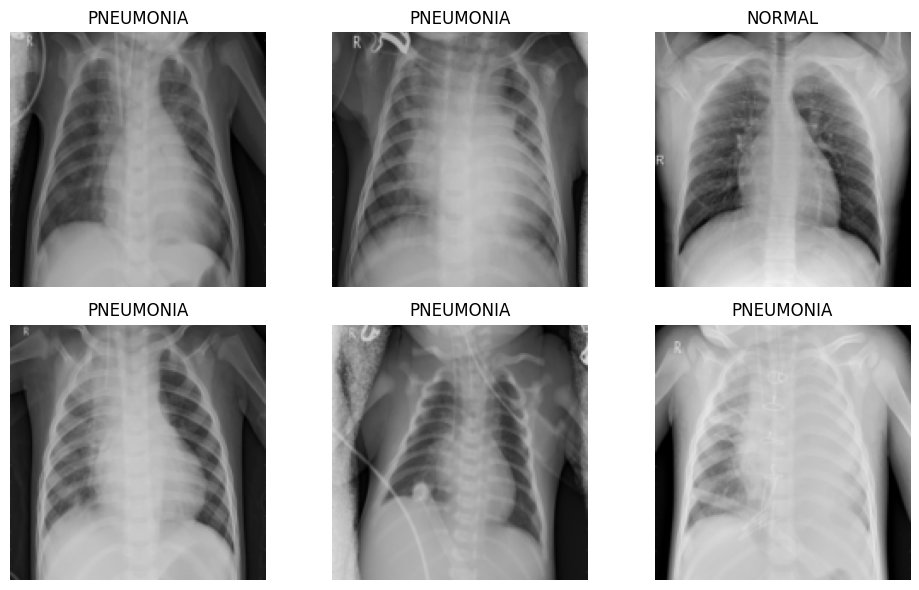

In [17]:
images, labels = next(iter(baseline_train_loader))

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    image = images[i].permute(1, 2, 0)

    plt.imshow(image)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 2.5 Baseline CNN Architecture

In [18]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 37 * 37, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = BaselineCNN().to(device)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 2.6 Baseline Training Function

In [19]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )

    return train_losses, val_losses, train_accuracies, val_accuracies

## 2.7 Baseline Model Training

In [20]:
baseline_criterion = nn.CrossEntropyLoss()

baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

baseline_epochs = 4

baseline_train_losses, baseline_val_losses, baseline_train_accs, baseline_val_accs = train_model(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    baseline_criterion,
    baseline_optimizer,
    baseline_epochs
)

Epoch [1/4] Train Loss: 0.2498 Train Acc: 0.8921 Val Loss: 0.2795 Val Acc: 0.9375
Epoch [2/4] Train Loss: 0.0887 Train Acc: 0.9672 Val Loss: 0.6274 Val Acc: 0.7500
Epoch [3/4] Train Loss: 0.0918 Train Acc: 0.9634 Val Loss: 0.3815 Val Acc: 0.8125
Epoch [4/4] Train Loss: 0.0620 Train Acc: 0.9757 Val Loss: 0.2357 Val Acc: 0.8125


## 2.8 Baseline Training Graphs

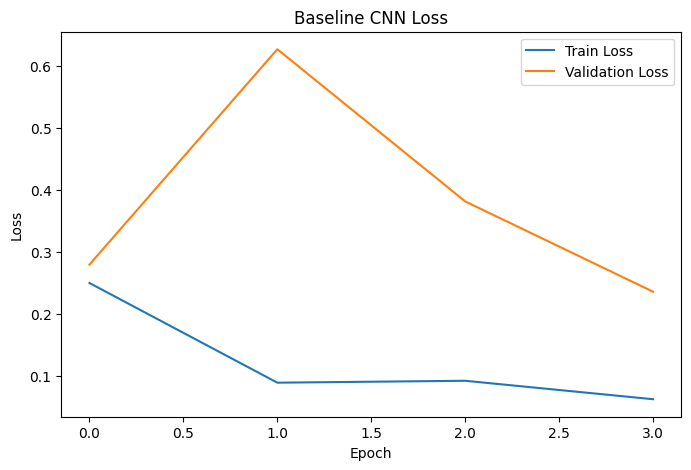

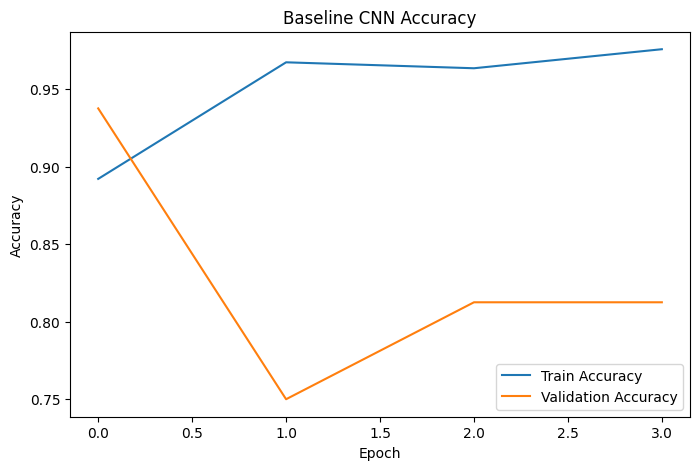

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(baseline_train_losses, label="Train Loss")
plt.plot(baseline_val_losses, label="Validation Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(baseline_train_accs, label="Train Accuracy")
plt.plot(baseline_val_accs, label="Validation Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 2.9 Baseline Evaluation Function

In [25]:
baseline_model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in baseline_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = baseline_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

baseline_accuracy = correct / total

print("Baseline CNN Accuracy:", baseline_accuracy)
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))

Baseline CNN Accuracy: 0.7083333333333334

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.23      0.37       234
   PNEUMONIA       0.68      0.99      0.81       390

    accuracy                           0.71       624
   macro avg       0.82      0.61      0.59       624
weighted avg       0.79      0.71      0.65       624



## 2.10 Baseline Model Evaluation

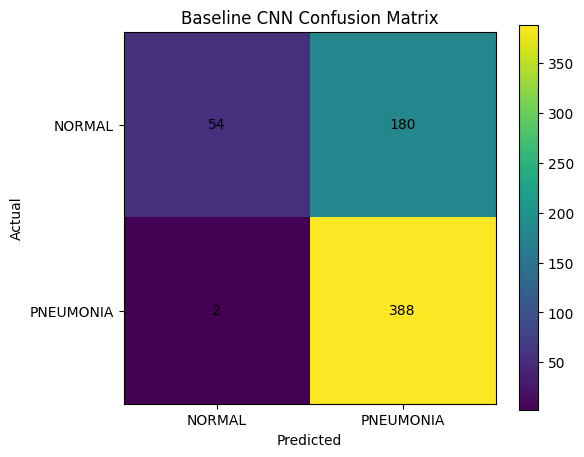

In [26]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Baseline CNN Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# 3. Improved CNN

## 3.1 Improved CNN Image Preprocessing

In [27]:
improved_train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

improved_test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 3.2 Improved CNN Dataset Loading

In [28]:
improved_train_dataset = datasets.ImageFolder(
    train_dir,
    transform=improved_train_transform
)

improved_val_dataset = datasets.ImageFolder(
    val_dir,
    transform=improved_test_transform
)

improved_test_dataset = datasets.ImageFolder(
    test_dir,
    transform=improved_test_transform
)

print("Classes:", improved_train_dataset.classes)

Classes: ['NORMAL', 'PNEUMONIA']


## 3.3 Improved CNN Data Loaders

In [29]:
improved_batch_size = 16

improved_train_loader = DataLoader(
    improved_train_dataset,
    batch_size=improved_batch_size,
    shuffle=True
)

improved_val_loader = DataLoader(
    improved_val_dataset,
    batch_size=improved_batch_size,
    shuffle=False
)

improved_test_loader = DataLoader(
    improved_test_dataset,
    batch_size=improved_batch_size,
    shuffle=False
)

## 3.4 Class Weighting

In [30]:
normal_count = count_images(train_dir)["NORMAL"]
pneumonia_count = count_images(train_dir)["PNEUMONIA"]

total_count = normal_count + pneumonia_count

normal_weight = total_count / normal_count
pneumonia_weight = total_count / pneumonia_count

class_weights = torch.tensor(
    [normal_weight, pneumonia_weight],
    dtype=torch.float
).to(device)

print("Class weights:", class_weights)

Class weights: tensor([3.8882, 1.3462])


## 3.5 Improved CNN Architecture

In [31]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


improved_model = ImprovedCNN().to(device)

print(improved_model)

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=41472, out_features=256, bias=True)
    (2): ReLU()
    (3): Dro

## 3.6 Improved CNN Training

In [32]:
improved_criterion = nn.CrossEntropyLoss(weight=class_weights)

improved_optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.0005
)

improved_epochs = 6

improved_train_losses, improved_val_losses, improved_train_accs, improved_val_accs = train_model(
    improved_model,
    improved_train_loader,
    improved_val_loader,
    improved_criterion,
    improved_optimizer,
    improved_epochs
)

Epoch [1/6] Train Loss: 0.5315 Train Acc: 0.8717 Val Loss: 0.5658 Val Acc: 0.8750
Epoch [2/6] Train Loss: 0.2124 Train Acc: 0.9160 Val Loss: 1.8354 Val Acc: 0.5625
Epoch [3/6] Train Loss: 0.1860 Train Acc: 0.9287 Val Loss: 0.4237 Val Acc: 0.8125
Epoch [4/6] Train Loss: 0.1753 Train Acc: 0.9365 Val Loss: 0.2687 Val Acc: 0.8125
Epoch [5/6] Train Loss: 0.1561 Train Acc: 0.9371 Val Loss: 0.4029 Val Acc: 0.8750
Epoch [6/6] Train Loss: 0.1517 Train Acc: 0.9494 Val Loss: 1.1581 Val Acc: 0.6875


## 3.7 Improved CNN Training Graphs

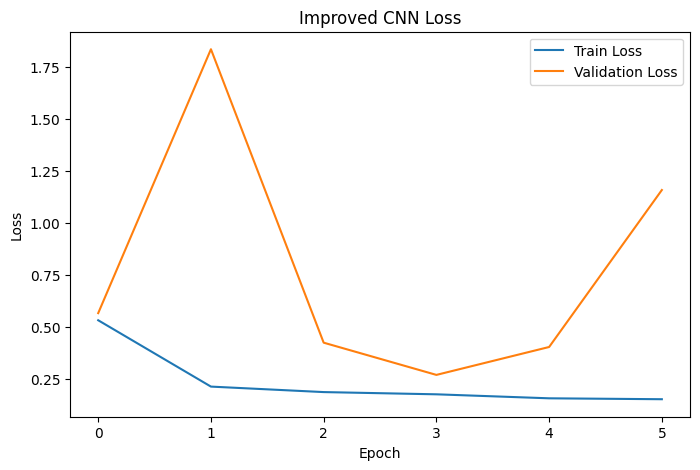

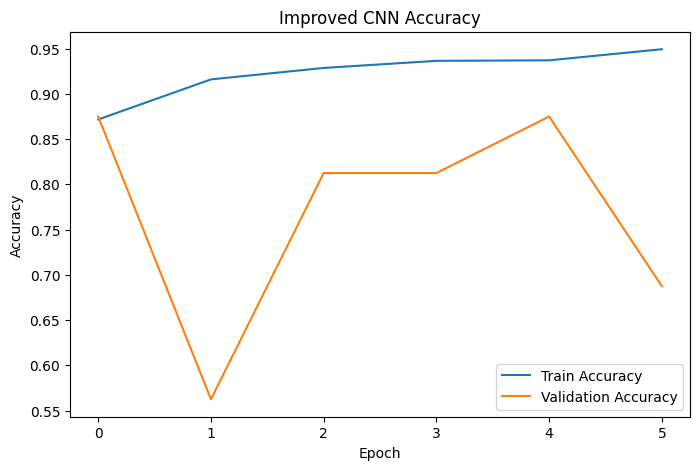

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(improved_train_losses, label="Train Loss")
plt.plot(improved_val_losses, label="Validation Loss")
plt.title("Improved CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(improved_train_accs, label="Train Accuracy")
plt.plot(improved_val_accs, label="Validation Accuracy")
plt.title("Improved CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 3.8 Improved CNN Evaluation

In [34]:
improved_model.eval()

correct = 0
total = 0

improved_labels = []
improved_predictions = []

with torch.no_grad():
    for images, labels in improved_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = improved_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        improved_labels.extend(labels.cpu().numpy())
        improved_predictions.extend(predicted.cpu().numpy())

improved_accuracy = correct / total

print("Improved CNN Accuracy:", improved_accuracy)
print("\nClassification Report:")
print(classification_report(improved_labels, improved_predictions, target_names=class_names))

Improved CNN Accuracy: 0.7900641025641025

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.45      0.62       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.72      0.74       624
weighted avg       0.84      0.79      0.77       624



## 3.9 Improved CNN Confusion Matrix


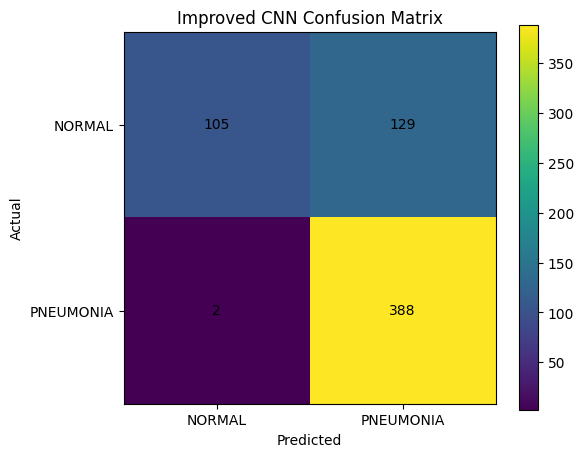

In [35]:
cm = confusion_matrix(improved_labels, improved_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Improved CNN Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 3.10 Baseline CNN vs Improved CNN

In [36]:
baseline_precision = precision_score(all_labels, all_predictions, average="weighted")
baseline_recall = recall_score(all_labels, all_predictions, average="weighted")
baseline_f1 = f1_score(all_labels, all_predictions, average="weighted")

improved_precision = precision_score(improved_labels, improved_predictions, average="weighted")
improved_recall = recall_score(improved_labels, improved_predictions, average="weighted")
improved_f1 = f1_score(improved_labels, improved_predictions, average="weighted")

comparison_results = {
    "Model": ["Baseline CNN", "Improved CNN"],
    "Accuracy": [baseline_accuracy, improved_accuracy],
    "Precision": [baseline_precision, improved_precision],
    "Recall": [baseline_recall, improved_recall],
    "F1-score": [baseline_f1, improved_f1]
}

comparison_results

{'Model': ['Baseline CNN', 'Improved CNN'],
 'Accuracy': [0.7083333333333334, 0.7900641025641025],
 'Precision': [0.7885437625754528, 0.8370428785769807],
 'Recall': [0.7083333333333334, 0.7900641025641025],
 'F1-score': [0.6459182204304946, 0.7656682951433459]}

# 4. Pretrained CNN ResNet18

## 4.1 ResNet18 Image Preprocessing

In [37]:
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 4.2 ResNet18 Dataset Loading

In [38]:
resnet_train_dataset = datasets.ImageFolder(
    train_dir,
    transform=resnet_train_transform
)

resnet_val_dataset = datasets.ImageFolder(
    val_dir,
    transform=resnet_test_transform
)

resnet_test_dataset = datasets.ImageFolder(
    test_dir,
    transform=resnet_test_transform
)

print("Classes:", resnet_train_dataset.classes)

Classes: ['NORMAL', 'PNEUMONIA']


## 4.3 ResNet18 Data Loaders

In [39]:
resnet_batch_size = 16

resnet_train_loader = DataLoader(
    resnet_train_dataset,
    batch_size=resnet_batch_size,
    shuffle=True
)

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=resnet_batch_size,
    shuffle=False
)

resnet_test_loader = DataLoader(
    resnet_test_dataset,
    batch_size=resnet_batch_size,
    shuffle=False
)

## 4.4 Load Pretrained ResNet18

In [40]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet_model.parameters():
    param.requires_grad = False

num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(num_features, 2)

resnet_model = resnet_model.to(device)

print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4.5 ResNet18 Training

In [41]:
resnet_criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

resnet_epochs = 5

resnet_train_losses, resnet_val_losses, resnet_train_accs, resnet_val_accs = train_model(
    resnet_model,
    resnet_train_loader,
    resnet_val_loader,
    resnet_criterion,
    resnet_optimizer,
    resnet_epochs
)

Epoch [1/5] Train Loss: 0.2797 Train Acc: 0.8829 Val Loss: 0.4070 Val Acc: 0.6875
Epoch [2/5] Train Loss: 0.1897 Train Acc: 0.9218 Val Loss: 0.5560 Val Acc: 0.6875
Epoch [3/5] Train Loss: 0.1621 Train Acc: 0.9356 Val Loss: 0.4059 Val Acc: 0.6875
Epoch [4/5] Train Loss: 0.1650 Train Acc: 0.9317 Val Loss: 0.6046 Val Acc: 0.6875
Epoch [5/5] Train Loss: 0.1507 Train Acc: 0.9377 Val Loss: 0.6672 Val Acc: 0.6875


## 4.6 ResNet18 Training Graphs

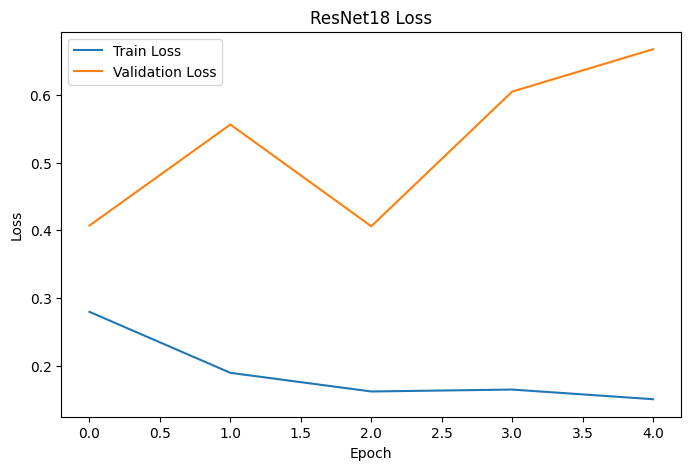

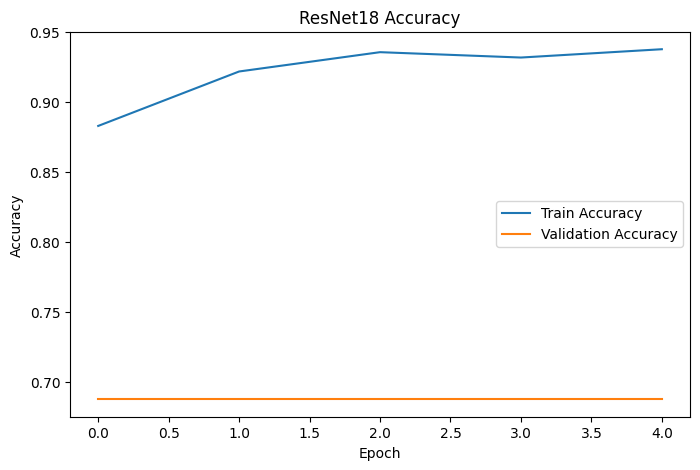

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(resnet_train_losses, label="Train Loss")
plt.plot(resnet_val_losses, label="Validation Loss")
plt.title("ResNet18 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(resnet_train_accs, label="Train Accuracy")
plt.plot(resnet_val_accs, label="Validation Accuracy")
plt.title("ResNet18 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 4.7 ResNet18 Evaluation

In [43]:
resnet_model.eval()

correct = 0
total = 0

resnet_labels = []
resnet_predictions = []

with torch.no_grad():
    for images, labels in resnet_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        resnet_labels.extend(labels.cpu().numpy())
        resnet_predictions.extend(predicted.cpu().numpy())

resnet_accuracy = correct / total

print("ResNet18 Accuracy:", resnet_accuracy)
print("\nClassification Report:")
print(classification_report(resnet_labels, resnet_predictions, target_names=class_names))

ResNet18 Accuracy: 0.8381410256410257

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.58      0.73       234
   PNEUMONIA       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



## 4.8 ResNet18 Confusion Matrix


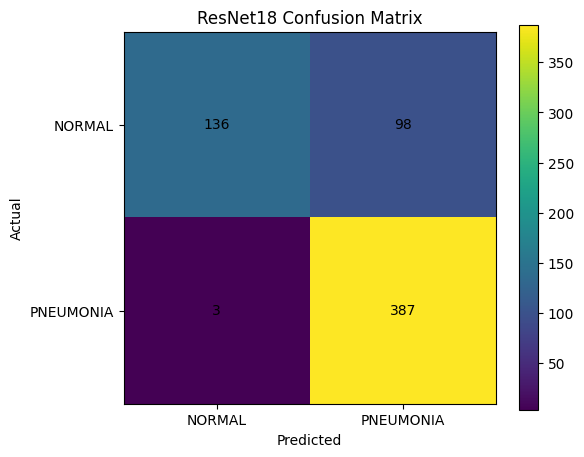

In [44]:
cm = confusion_matrix(resnet_labels, resnet_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("ResNet18 Confusion Matrix")
plt.colorbar()

plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

# 5. Model Comparison

In [45]:
resnet_precision = precision_score(resnet_labels, resnet_predictions, average="weighted")
resnet_recall = recall_score(resnet_labels, resnet_predictions, average="weighted")
resnet_f1 = f1_score(resnet_labels, resnet_predictions, average="weighted")

model_results = {
    "Model": ["Baseline CNN", "Improved CNN", "ResNet18"],
    "Accuracy": [baseline_accuracy, improved_accuracy, resnet_accuracy],
    "Precision": [baseline_precision, improved_precision, resnet_precision],
    "Recall": [baseline_recall, improved_recall, resnet_recall],
    "F1-score": [baseline_f1, improved_f1, resnet_f1]
}

model_results

{'Model': ['Baseline CNN', 'Improved CNN', 'ResNet18'],
 'Accuracy': [0.7083333333333334, 0.7900641025641025, 0.8381410256410257],
 'Precision': [0.7885437625754528, 0.8370428785769807, 0.8656178150263295],
 'Recall': [0.7083333333333334, 0.7900641025641025, 0.8381410256410257],
 'F1-score': [0.6459182204304946, 0.7656682951433459, 0.8263155878973573]}

## 5.1 Model Comparison Table


In [48]:
import pandas as pd

model_results_df = pd.DataFrame(model_results)
model_results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Baseline CNN,0.708333,0.788544,0.708333,0.645918
1,Improved CNN,0.790064,0.837043,0.790064,0.765668
2,ResNet18,0.838141,0.865618,0.838141,0.826316


## 5.2 Model Performance Bar Chart


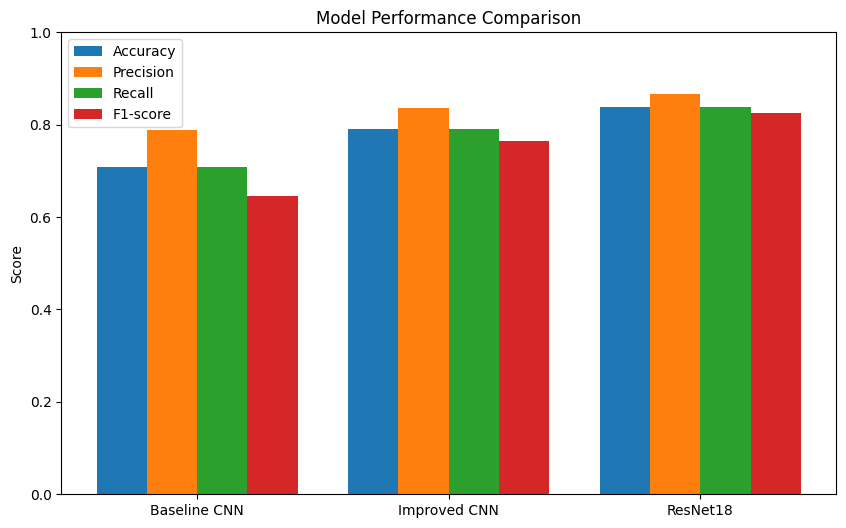

In [49]:
models_list = model_results["Model"]
accuracy_scores = model_results["Accuracy"]
precision_scores = model_results["Precision"]
recall_scores = model_results["Recall"]
f1_scores = model_results["F1-score"]

x = np.arange(len(models_list))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 0.3, accuracy_scores, width, label="Accuracy")
plt.bar(x - 0.1, precision_scores, width, label="Precision")
plt.bar(x + 0.1, recall_scores, width, label="Recall")
plt.bar(x + 0.3, f1_scores, width, label="F1-score")

plt.xticks(x, models_list)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.ylim(0, 1)

plt.show()

## 5.3 Normalized Confusion Matrices


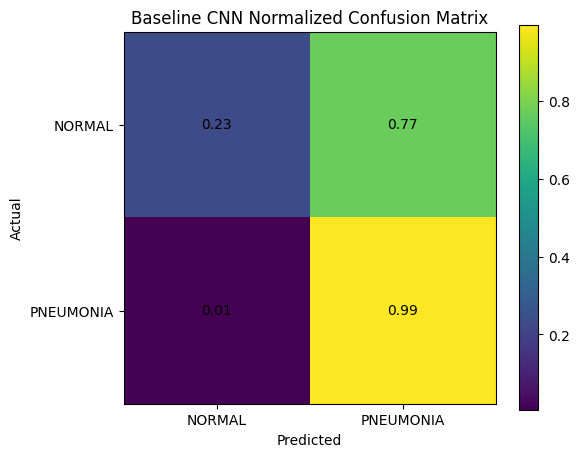

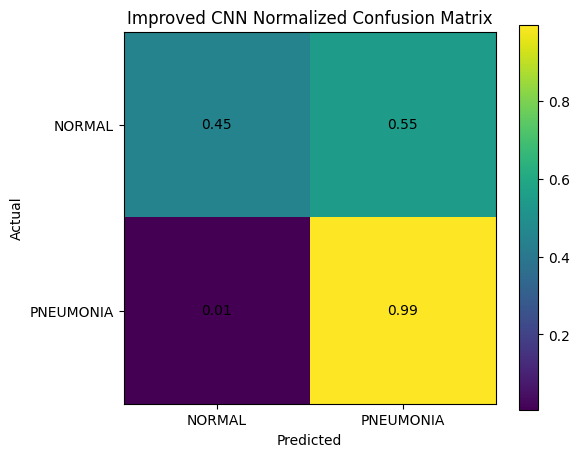

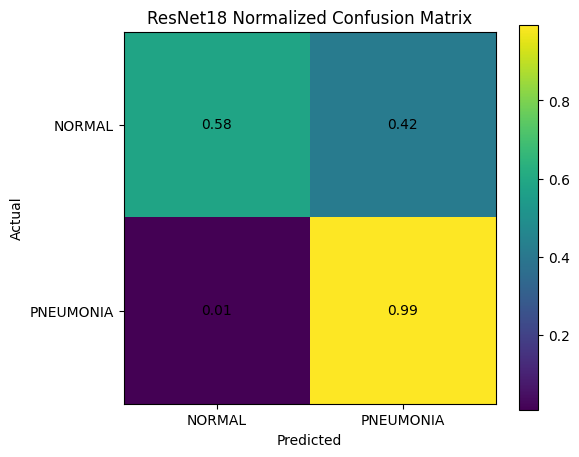

In [50]:
def plot_normalized_confusion_matrix(labels, predictions, title):
    cm = confusion_matrix(labels, predictions)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_normalized)
    plt.title(title)
    plt.colorbar()

    plt.xticks([0, 1], class_names)
    plt.yticks([0, 1], class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center")

    plt.show()


plot_normalized_confusion_matrix(all_labels, all_predictions, "Baseline CNN Normalized Confusion Matrix")
plot_normalized_confusion_matrix(improved_labels, improved_predictions, "Improved CNN Normalized Confusion Matrix")
plot_normalized_confusion_matrix(resnet_labels, resnet_predictions, "ResNet18 Normalized Confusion Matrix")


## 5.4 Per-Class F1-Score Comparison


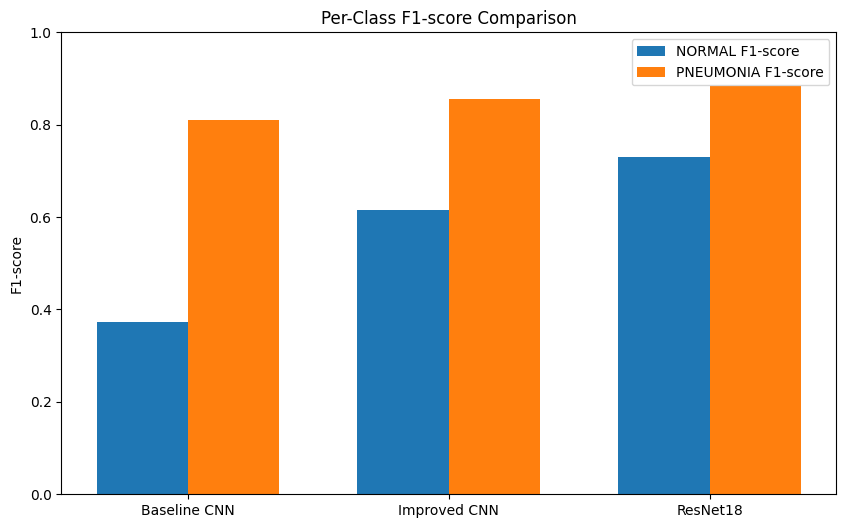

In [51]:
baseline_report = classification_report(all_labels, all_predictions, target_names=class_names, output_dict=True)
improved_report = classification_report(improved_labels, improved_predictions, target_names=class_names, output_dict=True)
resnet_report = classification_report(resnet_labels, resnet_predictions, target_names=class_names, output_dict=True)

normal_f1_scores = [
    baseline_report["NORMAL"]["f1-score"],
    improved_report["NORMAL"]["f1-score"],
    resnet_report["NORMAL"]["f1-score"]
]

pneumonia_f1_scores = [
    baseline_report["PNEUMONIA"]["f1-score"],
    improved_report["PNEUMONIA"]["f1-score"],
    resnet_report["PNEUMONIA"]["f1-score"]
]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, normal_f1_scores, width, label="NORMAL F1-score")
plt.bar(x + width / 2, pneumonia_f1_scores, width, label="PNEUMONIA F1-score")

plt.xticks(x, models_list)
plt.ylabel("F1-score")
plt.title("Per-Class F1-score Comparison")
plt.ylim(0, 1)
plt.legend()
plt.show()


## 5.5 Best Model Selection


In [52]:
best_accuracy = max(
    baseline_accuracy,
    improved_accuracy,
    resnet_accuracy
)

if best_accuracy == baseline_accuracy:
    best_model_name = "Baseline CNN"
    best_model = baseline_model

elif best_accuracy == improved_accuracy:
    best_model_name = "Improved CNN"
    best_model = improved_model

else:
    best_model_name = "ResNet18"
    best_model = resnet_model

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: ResNet18
Best Accuracy: 0.8381410256410257
